# CosMx Human Colon To AnnData

This notebook is set up for two phases:

1. Explore the raw CosMx metadata and expression inputs safely.
2. Build a sparse, KaroSpace-ready `.h5ad` with `obsm["spatial"]`.

The raw files currently point at:

- `/Users/chrislangseth/Downloads/S0_metadata_file.csv.gz`
- `/Users/chrislangseth/Downloads/S0_exprMat_file.csv.gz`

The expression file is very large, so the notebook uses chunked loading and sparse assembly instead of trying to hold the full dense matrix in memory.


In [1]:
from __future__ import annotations

import os
from pathlib import Path

os.environ.setdefault("KMP_WARNINGS", "0")
os.environ.setdefault("NUMBA_CACHE_DIR", str(Path.cwd() / ".numba_cache"))
os.environ.setdefault("MPLCONFIGDIR", str(Path.cwd() / ".mplconfig"))

import json
import gc

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import sparse

ad.settings.allow_write_nullable_strings = True

sns.set_theme(context="notebook", style="whitegrid")
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 100)

ROOT = Path.cwd().resolve()
METADATA_PATH = Path("/Users/chrislangseth/Downloads/S0_metadata_file.csv.gz")
EXPR_PATH = Path("/Users/chrislangseth/Downloads/S0_exprMat_file.csv.gz")
OUTPUT_DIR = ROOT / "data" / "processed" / "cosmx-human-colon"
OUTPUT_PATH = OUTPUT_DIR / "cosmx-human-colon.h5ad"

CHUNKSIZE = 2_000
SELECT_FOVS = None
MAX_CELLS = 25_000
WRITE_OUTPUT = False

ROOT, METADATA_PATH.exists(), EXPR_PATH.exists(), OUTPUT_PATH


Matplotlib is building the font cache; this may take a moment.


(PosixPath('/Users/chrislangseth/work/karolinska_institutet/projects/KaroSpaceDataWrangling/notebooks'),
 True,
 True,
 PosixPath('/Users/chrislangseth/work/karolinska_institutet/projects/KaroSpaceDataWrangling/notebooks/data/processed/cosmx-human-colon/cosmx-human-colon.h5ad'))

## Input inspection

Read only the metadata and the expression header first. This is cheap and gives enough context to decide whether the chunked build parameters are sensible.


In [2]:
metadata = pd.read_csv(METADATA_PATH, compression="gzip")
expr_header = pd.read_csv(EXPR_PATH, compression="gzip", nrows=5)

gene_cols = [c for c in expr_header.columns if c not in {"fov", "cell_ID"}]

print("metadata shape:", metadata.shape)
print("expression preview shape:", expr_header.shape)
print("gene columns:", len(gene_cols))
print("metadata columns:", metadata.columns.tolist())

metadata.head()


metadata shape: (493834, 68)
expression preview shape: (5, 20380)
gene columns: 20378
metadata columns: ['fov', 'Area', 'AspectRatio', 'Width', 'Height', 'Mean.B', 'Max.B', 'Mean.G', 'Max.G', 'Mean.Y', 'Max.Y', 'Mean.R', 'Max.R', 'Mean.DAPI', 'Max.DAPI', 'SplitRatioToLocal', 'NucArea', 'NucAspectRatio', 'Circularity', 'Eccentricity', 'Perimeter', 'Solidity', 'cell_id', 'version', 'dualfiles', 'Run_name', 'Run_Tissue_name', 'ISH.concentration', 'Dash', 'tissue', 'Panel', 'assay_type', 'slide_ID', 'cell_ID', 'unassignedTranscripts', 'median_RNA', 'RNA_quantile_0.75', 'RNA_quantile_0.8', 'RNA_quantile_0.85', 'RNA_quantile_0.9', 'RNA_quantile_0.95', 'RNA_quantile_0.99', 'nCount_RNA', 'nFeature_RNA', 'median_negprobes', 'negprobes_quantile_0.75', 'negprobes_quantile_0.8', 'negprobes_quantile_0.85', 'negprobes_quantile_0.9', 'negprobes_quantile_0.95', 'negprobes_quantile_0.99', 'nCount_negprobes', 'nFeature_negprobes', 'median_falsecode', 'falsecode_quantile_0.75', 'falsecode_quantile_0.8', 

,fov,Area,AspectRatio,Width,Height,Mean.B,Max.B,Mean.G,Max.G,Mean.Y,Max.Y,Mean.R,Max.R,Mean.DAPI,Max.DAPI,SplitRatioToLocal,NucArea,NucAspectRatio,Circularity,Eccentricity,Perimeter,Solidity,cell_id,version,dualfiles,Run_name,Run_Tissue_name,ISH.concentration,Dash,tissue,Panel,assay_type,slide_ID,cell_ID,unassignedTranscripts,median_RNA,RNA_quantile_0.75,RNA_quantile_0.8,RNA_quantile_0.85,RNA_quantile_0.9,RNA_quantile_0.95,RNA_quantile_0.99,nCount_RNA,nFeature_RNA,median_negprobes,negprobes_quantile_0.75,negprobes_quantile_0.8,negprobes_quantile_0.85,negprobes_quantile_0.9,negprobes_quantile_0.95,negprobes_quantile_0.99,nCount_negprobes,nFeature_negprobes,median_falsecode,falsecode_quantile_0.75,falsecode_quantile_0.8,falsecode_quantile_0.85,falsecode_quantile_0.9,falsecode_quantile_0.95,falsecode_quantile_0.99,nCount_falsecode,nFeature_falsecode,Area.um2,CenterX_local_px,CenterY_local_px,CenterX_global_px,CenterY_global_px,cell
0,1,1782,0.43,77,33,64720,64720,465,820,17017,50984,772,1604,1791,3284,0.33,1240,0.68,2.70,0.56,91,19.58,c_1_1_1,v6,?,Run0,S0,1nM,PILOT,tissue,WTx,RNA,1,1,0.162095,40,63.0,71.0,83.0,102.0,142.0,343.66,50,46,25.0,32.0,33.2,35.65,39.5,44.0,59.53,0,0,8,13,16.0,18.0,23.0,45.4,77.08,2,1,25.6608,3720,16,76063.0,114896.0,c_1_1_1
1,1,19639,0.97,152,156,56008,64720,351,696,11971,35152,543,2148,1215,3156,3.63,5860,0.79,0.92,0.78,518,37.91,c_1_1_2,v6,?,Run0,S0,1nM,PILOT,tissue,WTx,RNA,1,2,0.162095,40,63.0,71.0,83.0,102.0,142.0,343.66,1018,843,25.0,32.0,33.2,35.65,39.5,44.0,59.53,2,2,8,13,16.0,18.0,23.0,45.4,77.08,27,26,282.8016,3884,78,76227.0,114834.0,c_1_1_2
2,1,5967,0.70,69,98,64706,64720,347,832,14484,34044,733,3252,1452,2904,1.10,3080,0.55,0.96,0.21,280,21.31,c_1_1_3,v6,?,Run0,S0,1nM,PILOT,tissue,WTx,RNA,1,3,0.162095,40,63.0,71.0,83.0,102.0,142.0,343.66,377,331,25.0,32.0,33.2,35.65,39.5,44.0,59.53,0,0,8,13,16.0,18.0,23.0,45.4,77.08,9,9,85.9248,3983,49,76326.0,114863.0,c_1_1_3
3,1,8642,0.87,117,102,64597,64720,290,908,11431,33548,602,2144,1929,2736,1.60,6064,0.86,0.86,0.64,356,24.28,c_1_1_4,v6,?,Run0,S0,1nM,PILOT,tissue,WTx,RNA,1,4,0.162095,40,63.0,71.0,83.0,102.0,142.0,343.66,381,346,25.0,32.0,33.2,35.65,39.5,44.0,59.53,0,0,8,13,16.0,18.0,23.0,45.4,77.08,4,4,124.4448,4071,51,76413.0,114861.0,c_1_1_4
4,1,4415,0.94,76,81,64720,64720,508,732,18489,41588,936,3512,1351,2440,0.82,2104,0.97,0.83,0.73,258,17.11,c_1_1_5,v6,?,Run0,S0,1nM,PILOT,tissue,WTx,RNA,1,5,0.162095,40,63.0,71.0,83.0,102.0,142.0,343.66,129,112,25.0,32.0,33.2,35.65,39.5,44.0,59.53,2,2,8,13,16.0,18.0,23.0,45.4,77.08,5,5,63.5760,3773,40,76116.0,114872.0,c_1_1_5


In [3]:
summary_cols = [
    "fov",
    "slide_ID",
    "Run_name",
    "Run_Tissue_name",
    "Panel",
    "assay_type",
    "nCount_RNA",
    "nFeature_RNA",
    "CenterX_global_px",
    "CenterY_global_px",
]

metadata[summary_cols].describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
fov,493834.0,NaN,NaN,NaN,165.680895,108.215081,1.0,74.0,150.0,236.0,400.0
slide_ID,493834.0,NaN,NaN,NaN,1.0,0.0,1.0,1.0,1.0,1.0,1.0
Run_name,493834,1,Run0,493834,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Run_Tissue_name,493834,1,S0,493834,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Panel,493834,1,WTx,493834,NaN,NaN,NaN,NaN,NaN,NaN,NaN
assay_type,493834,1,RNA,493834,NaN,NaN,NaN,NaN,NaN,NaN,NaN
nCount_RNA,493834.0,NaN,NaN,NaN,1680.342884,1457.939379,5.0,713.0,1258.0,2183.0,29055.0
nFeature_RNA,493834.0,NaN,NaN,NaN,1115.595089,829.593036,2.0,520.0,895.0,1489.0,10420.0
CenterX_global_px,493834.0,NaN,NaN,NaN,37633.546787,26845.638428,15.0,17218.0,30970.0,49451.0,114895.0
CenterY_global_px,493834.0,NaN,NaN,NaN,68360.618483,31862.709485,-4224.0,43695.0,76771.0,94582.0,116541.0


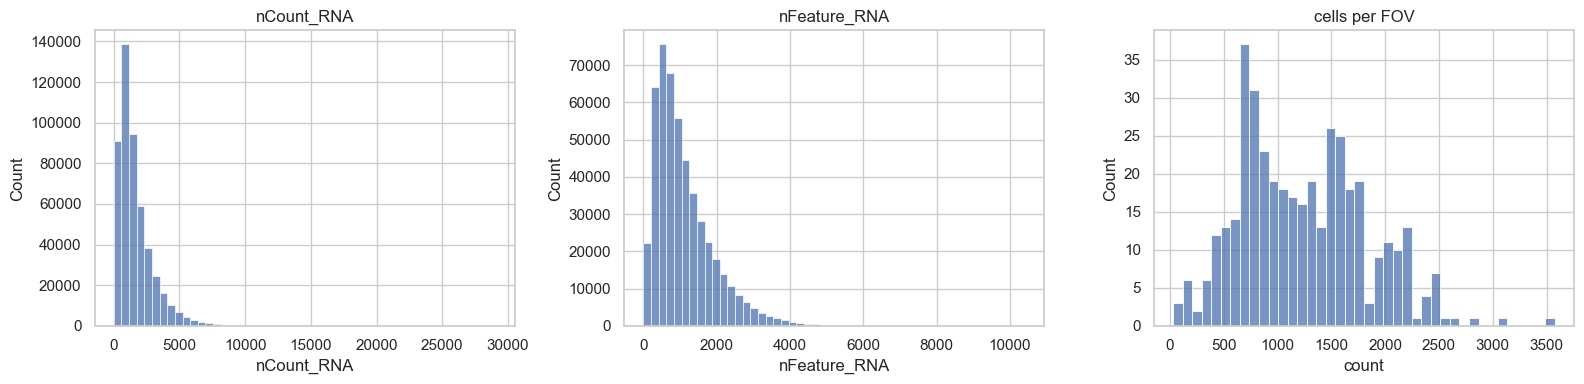

,fov,nCount_RNA,nFeature_RNA
0,1,50,46
1,1,1018,843
2,1,377,331
3,1,381,346
4,1,129,112


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.histplot(metadata["nCount_RNA"], bins=50, ax=axes[0])
axes[0].set_title("nCount_RNA")

sns.histplot(metadata["nFeature_RNA"], bins=50, ax=axes[1])
axes[1].set_title("nFeature_RNA")

fov_sizes = metadata["fov"].value_counts().sort_index()
sns.histplot(fov_sizes, bins=40, ax=axes[2])
axes[2].set_title("cells per FOV")

plt.tight_layout()
plt.show()

metadata[["fov", "nCount_RNA", "nFeature_RNA"]].head()


## Assembly helpers

The raw expression matrix is cell-by-gene CSV. The helpers below:

- build a stable observation key from `fov` + `cell_ID`
- align expression chunks against metadata
- create sparse matrices chunk-by-chunk
- sanitize `obs` dtypes so `.write_h5ad()` is reliable


In [5]:
def make_obs_key(df: pd.DataFrame) -> pd.Index:
    return (
        df["fov"].astype(str).str.strip()
        + "__"
        + df["cell_ID"].astype(str).str.strip()
    )


def sanitize_obs_for_h5ad(obs_df: pd.DataFrame) -> pd.DataFrame:
    out = obs_df.copy()
    for col in out.columns:
        ser = out[col]
        if isinstance(ser.dtype, pd.CategoricalDtype):
            if ser.cat.categories.dtype == object:
                out[col] = ser.astype("string")
            continue

        if pd.api.types.is_object_dtype(ser) or pd.api.types.is_string_dtype(ser):
            non_na = ser.dropna()
            if non_na.empty:
                out[col] = ser.astype("string")
                continue

            num = pd.to_numeric(ser, errors="coerce")
            if int(num.notna().sum()) == int(ser.notna().sum()):
                out[col] = num
                continue

            out[col] = ser.astype("string")

    return out


def prepare_metadata(metadata_df: pd.DataFrame) -> pd.DataFrame:
    obs = metadata_df.copy()
    obs["obs_key"] = make_obs_key(obs)
    if obs["obs_key"].duplicated().any():
        dupes = int(obs["obs_key"].duplicated().sum())
        raise ValueError(f"metadata has {dupes} duplicated fov/cell_ID keys")

    obs["dataset_id"] = "cosmx-human-colon"
    obs["sample_id"] = obs["Run_Tissue_name"].fillna("S0").astype(str)
    obs["section_id"] = obs["fov"].map(lambda x: f"fov_{int(x):03d}")

    obs["fov"] = obs["fov"].astype("int32")
    obs["cell_ID"] = obs["cell_ID"].astype("int32")
    obs["slide_ID"] = pd.to_numeric(obs["slide_ID"], errors="coerce").astype("Int32")

    for col in ["Run_name", "Run_Tissue_name", "Panel", "assay_type", "dataset_id", "sample_id", "section_id"]:
        if col in obs.columns:
            obs[col] = obs[col].astype("category")

    return obs.set_index("obs_key", drop=False)


def build_sparse_anndata(
    expr_path: Path,
    metadata_indexed: pd.DataFrame,
    *,
    chunksize: int = 2_000,
    select_fovs: list[int] | None = None,
    max_cells: int | None = None,
) -> ad.AnnData:
    preview = pd.read_csv(expr_path, compression="gzip", nrows=5)
    genes = [c for c in preview.columns if c not in {"fov", "cell_ID"}]

    matrices = []
    obs_parts = []
    gene_nnz = np.zeros(len(genes), dtype=np.int64)
    gene_sum = np.zeros(len(genes), dtype=np.int64)
    total_cells = 0
    matched_cells = 0

    for chunk_idx, chunk in enumerate(pd.read_csv(expr_path, compression="gzip", chunksize=chunksize), start=1):
        chunk["obs_key"] = make_obs_key(chunk)

        if select_fovs is not None:
            chunk = chunk[chunk["fov"].isin(select_fovs)].copy()

        if chunk.empty:
            continue

        if max_cells is not None:
            remaining = max_cells - matched_cells
            if remaining <= 0:
                break
            chunk = chunk.iloc[:remaining].copy()

        obs_chunk = metadata_indexed.reindex(chunk["obs_key"])
        if obs_chunk["obs_key"].isna().any():
            missing = chunk.loc[obs_chunk["obs_key"].isna(), ["fov", "cell_ID", "obs_key"]].head(10)
            raise ValueError(f"missing metadata for some expression rows:\n{missing}")

        values = chunk[genes].to_numpy(dtype=np.int32, copy=False)
        gene_nnz += (values != 0).sum(axis=0)
        gene_sum += values.sum(axis=0)
        matrices.append(sparse.csr_matrix(values))

        obs_part = obs_chunk.copy()
        obs_part.index = obs_part["cell"].astype(str) if "cell" in obs_part.columns and obs_part["cell"].notna().all() else obs_part["obs_key"]
        obs_parts.append(obs_part)

        total_cells += len(chunk)
        matched_cells += len(obs_part)
        print(f"chunk {chunk_idx}: kept {len(chunk):,} cells; cumulative {matched_cells:,}")

        del chunk, obs_chunk, values, obs_part
        gc.collect()

    if not matrices:
        raise ValueError("no expression rows selected; check SELECT_FOVS / MAX_CELLS")

    X = sparse.vstack(matrices, format="csr")
    obs = pd.concat(obs_parts, axis=0)
    obs = sanitize_obs_for_h5ad(obs)

    var = pd.DataFrame(index=pd.Index(genes, name="gene"))
    var["feature_name"] = var.index.astype(str)
    var["feature_type"] = "gene"
    var["n_cells_by_counts"] = gene_nnz
    var["total_counts"] = gene_sum

    nonzero_gene_mask = var["n_cells_by_counts"].to_numpy() > 0
    if not np.all(nonzero_gene_mask):
        X = X[:, nonzero_gene_mask]
        var = var.loc[nonzero_gene_mask].copy()

    adata = ad.AnnData(X=X, obs=obs, var=var)
    adata.obsm["spatial"] = adata.obs[["CenterX_global_px", "CenterY_global_px"]].to_numpy(dtype=np.float32)
    adata.uns["dataset_source"] = {
        "metadata_path": str(METADATA_PATH),
        "expression_path": str(expr_path),
        "chunksize": int(chunksize),
        "selected_fovs": None if select_fovs is None else [int(x) for x in select_fovs],
        "max_cells": None if max_cells is None else int(max_cells),
    }
    adata.uns["karospace_hints"] = {
        "section_key": "section_id",
        "sample_key": "sample_id",
        "spatial_key": "spatial",
        "notes": [
            "raw CosMx inputs do not include cell-type labels in this export",
            "good initial metadata filters are fov, sample_id, nCount_RNA, and nFeature_RNA",
        ],
    }
    return adata


In [6]:
metadata_indexed = prepare_metadata(metadata)
metadata_indexed[[
    "obs_key",
    "cell",
    "fov",
    "cell_ID",
    "section_id",
    "sample_id",
    "CenterX_global_px",
    "CenterY_global_px",
]].head()


,obs_key,cell,fov,cell_ID,section_id,sample_id,CenterX_global_px,CenterY_global_px
obs_key,,,,,,,,
1__1,1__1,c_1_1_1,1,1,fov_001,S0,76063.0,114896.0
1__2,1__2,c_1_1_2,1,2,fov_001,S0,76227.0,114834.0
1__3,1__3,c_1_1_3,1,3,fov_001,S0,76326.0,114863.0
1__4,1__4,c_1_1_4,1,4,fov_001,S0,76413.0,114861.0
1__5,1__5,c_1_1_5,1,5,fov_001,S0,76116.0,114872.0


## Preview build

The defaults below are intentionally conservative:

- `MAX_CELLS = 25_000` keeps the first assembly pass manageable.
- Set `MAX_CELLS = None` for the full dataset.
- Set `WRITE_OUTPUT = True` only when you are ready to write the final `.h5ad`.


In [ ]:
adata = build_sparse_anndata(
    EXPR_PATH,
    metadata_indexed,
    chunksize=CHUNKSIZE,
    select_fovs=SELECT_FOVS,
    max_cells=MAX_CELLS,
)

adata


chunk 1: kept 2,000 cells; cumulative 2,000
chunk 2: kept 2,000 cells; cumulative 4,000
chunk 3: kept 2,000 cells; cumulative 6,000


In [ ]:
print("obs x vars:", adata.n_obs, adata.n_vars)
print("X format:", type(adata.X), "nnz:", adata.X.nnz)
print("obsm keys:", list(adata.obsm.keys()))
print("obs columns:", len(adata.obs.columns))
print("var columns:", len(adata.var.columns))

adata.obs[[
    "dataset_id",
    "sample_id",
    "section_id",
    "fov",
    "cell_ID",
    "nCount_RNA",
    "nFeature_RNA",
]].head()


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(
    adata.obsm["spatial"][:, 0],
    adata.obsm["spatial"][:, 1],
    s=0.2,
    c=adata.obs["nCount_RNA"].to_numpy(),
    cmap="viridis",
)
axes[0].set_title("Spatial coordinates colored by nCount_RNA")
axes[0].set_xlabel("CenterX_global_px")
axes[0].set_ylabel("CenterY_global_px")
axes[0].invert_yaxis()

top_fovs = adata.obs["fov"].value_counts().head(20).sort_index()
sns.barplot(x=top_fovs.index.astype(str), y=top_fovs.values, ax=axes[1], color="#4c72b0")
axes[1].set_title("Top FOV cell counts in current build")
axes[1].set_xlabel("fov")
axes[1].set_ylabel("cells")
axes[1].tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.show()


## Full export

For the final uploadable file:

1. Set `MAX_CELLS = None`.
2. Optionally set `SELECT_FOVS` if you want a partial export.
3. Re-run the build cell.
4. Set `WRITE_OUTPUT = True` and run the write cell below.


In [ ]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

if WRITE_OUTPUT:
    adata.write_h5ad(OUTPUT_PATH)
    print(f"Wrote: {OUTPUT_PATH}")
else:
    print("WRITE_OUTPUT is False; notebook is configured for inspection first.")
    print(f"Planned output: {OUTPUT_PATH}")


In [ ]:
karospace_summary = {
    "output_path": str(OUTPUT_PATH),
    "section_key": "section_id",
    "sample_key": "sample_id",
    "spatial_key": "obsm['spatial']",
    "candidate_filter_columns": ["fov", "sample_id", "nCount_RNA", "nFeature_RNA"],
    "annotation_gap": "raw input does not yet include a moderate-cardinality cell annotation",
}

print(json.dumps(karospace_summary, indent=2))
